# Teorema del Límite Central (TLC) y Colas M/M/1

## Objetivos de Aprendizaje
1. Entender el Teorema del Límite Central: enunciado formal y condiciones
2. Aplicar TLC a distribuciones exponenciales
3. Simular sistemas de colas M/M/1 con teoría de Poisson
4. Conectar TLC con distribuciones muestrales
5. Validar resultados teóricos con simulaciones

## Contenidos
- **TLC**: Concepto, condiciones y aplicaciones
- **Teoría de Colas**: Notación de Kendall, Ley de Little, intensidad de tráfico ρ
- **Simulación Computacional**: Procesos de Poisson y tiempos exponenciales


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración para reproducibilidad
np.random.seed(42)
RANDOM_STATE = 42


In [2]:
def simulate_mm1_queue(arrival_rate, service_rate, n_customers=1000, random_state=42):
    """Simula una cola M/M/1 usando procesos de Poisson.

    La cola M/M/1 modela un sistema con un servidor, llegadas Poisson
    y tiempos de servicio exponenciales. La condición de estabilidad
    requiere que la tasa de llegada sea menor que la tasa de servicio (λ < μ).

    Args:
        arrival_rate (float): Tasa de llegada λ (clientes/unidad de tiempo).
        service_rate (float): Tasa de servicio μ (clientes/unidad de tiempo).
        n_customers (int): Número de clientes a simular.
        random_state (int): Semilla para reproducibilidad.

    Returns:
        dict: Diccionario con:
            - wait_times: tiempos de espera de cada cliente
            - service_times: tiempos de servicio de cada cliente
            - sojourn_times: tiempo total en el sistema (espera + servicio)
            - utilization: ρ = λ/μ (factor de utilización)
            - mean_wait_simulated: tiempo promedio de espera (simulado)
            - mean_wait_theoretical: tiempo promedio de espera (teórico)

    Raises:
        ValueError: Si arrival_rate >= service_rate (sistema inestable).

    Example:
        >>> results = simulate_mm1_queue(5, 7, n_customers=1000)
        >>> print(f"Espera promedio: {results['mean_wait_simulated']:.4f}")
    """
    # Validar estabilidad del sistema
    if arrival_rate >= service_rate:
        raise ValueError(
            f"Sistema inestable: λ ({arrival_rate}) debe ser < μ ({service_rate}). "
            f"Utilización ρ = λ/μ debe ser < 1 para convergencia."
        )

    rng = np.random.default_rng(random_state)

    # Tiempos entre llegadas (distribución exponencial)
    # E[interarrival] = 1/λ
    interarrival_times = rng.exponential(1/arrival_rate, n_customers)
    arrival_times = np.cumsum(interarrival_times)

    # Tiempos de servicio (distribución exponencial)
    # E[service] = 1/μ
    service_times = rng.exponential(1/service_rate, n_customers)

    # Calcular tiempos de inicio y fin de servicio
    # El cliente inicia servicio cuando llega O cuando el servidor se libera
    start_service = np.zeros(n_customers)
    finish_service = np.zeros(n_customers)

    start_service[0] = arrival_times[0]
    finish_service[0] = start_service[0] + service_times[0]

    for i in range(1, n_customers):
        start_service[i] = max(arrival_times[i], finish_service[i-1])
        finish_service[i] = start_service[i] + service_times[i]

    # Calcular métricas
    wait_times = start_service - arrival_times  # tiempo esperando en cola
    sojourn_times = finish_service - arrival_times  # tiempo total en sistema

    rho = arrival_rate / service_rate  # Utilización del servidor

    # Fórmula teórica de Erlang C para M/M/1: E[W] = ρ/(μ(1-ρ))
    theoretical_mean_wait = rho / (service_rate * (1 - rho))

    return {
        'wait_times': wait_times,
        'service_times': service_times,
        'sojourn_times': sojourn_times,
        'arrival_times': arrival_times,
        'start_service': start_service,
        'finish_service': finish_service,
        'utilization': rho,
        'mean_wait_simulated': np.mean(wait_times),
        'mean_wait_theoretical': theoretical_mean_wait,
        'arrival_rate': arrival_rate,
        'service_rate': service_rate,
    }


## Teorema del Límite Central (TLC)

### Enunciado Formal
Si X₁, X₂, ..., Xₙ son variables aleatorias independientes e idénticamente distribuidas con:
- Media μ
- Varianza σ²

Entonces, la distribución de la media muestral X̄ₙ = (1/n)∑Xᵢ converge a una distribución normal:

**X̄ₙ ~ N(μ, σ²/n)** conforme n → ∞

### Condiciones Requeridas
1. **Independencia**: Las observaciones deben ser independientes
2. **Idéntica Distribución**: Todas siguen la misma distribución
3. **Varianza Finita**: σ² debe ser finita
4. **Tamaño de Muestra**: Generalmente n ≥ 30 es suficiente

### Implicaciones Prácticas
- Las medias muestrales siguen distribuciones normales
- Permite hacer inferencias sobre la población
- Fundamental para intervalos de confianza y tests de hipótesis

### Ejemplo: TLC con Distribución Exponencial
Aunque la población es exponencial (sesgada), la distribución de medias muestrales será aproximadamente normal.


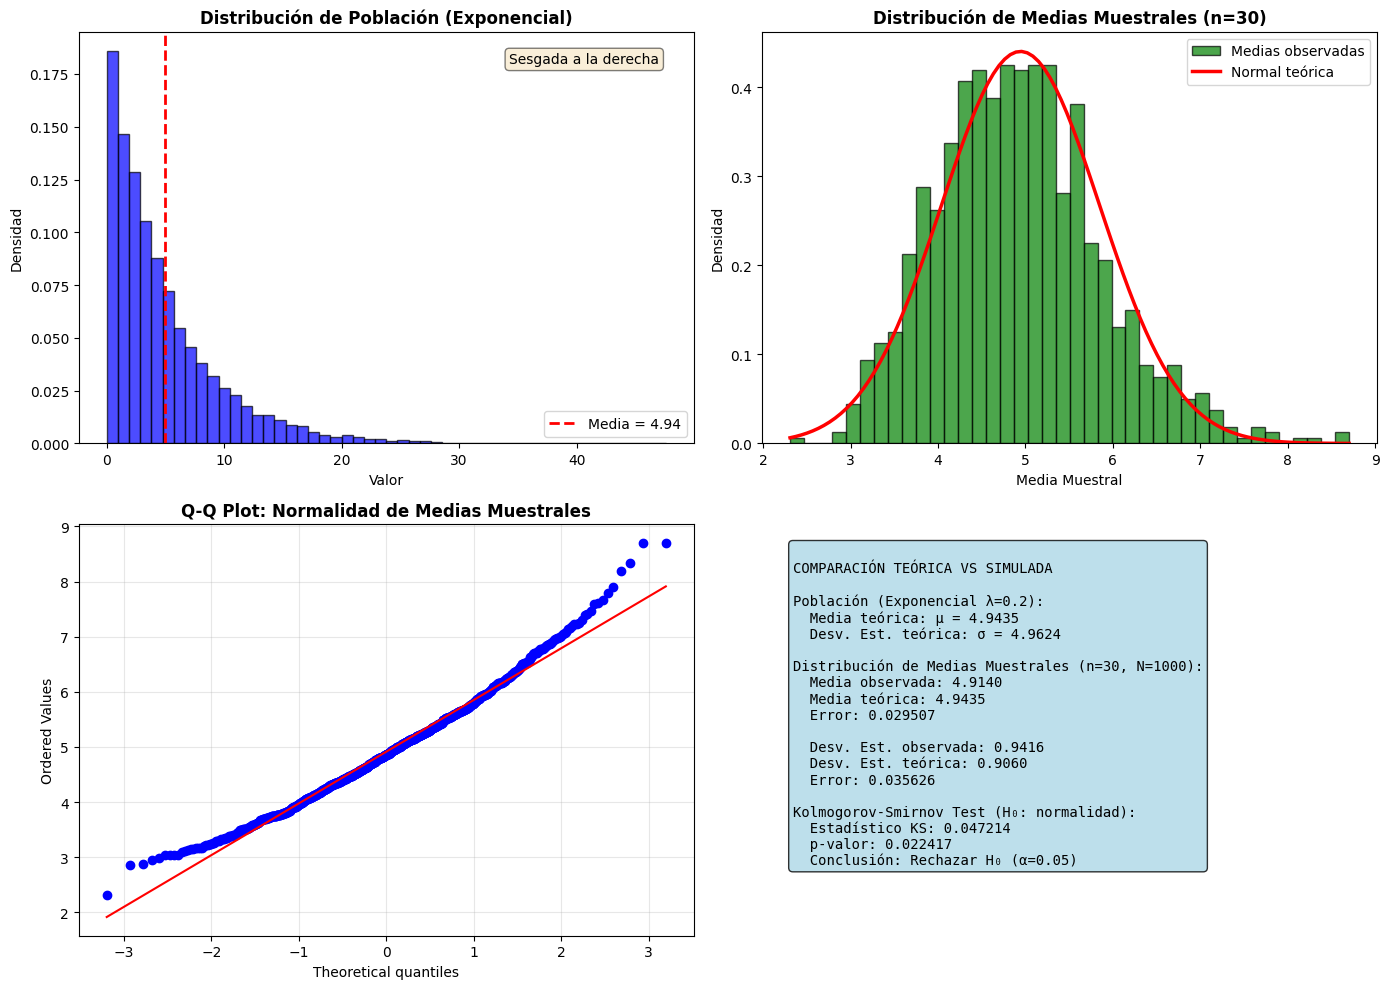

✓ Demostración del TLC completada exitosamente


In [3]:
# Demostración del Teorema del Límite Central

def central_limit_theorem_demo(sample_size=30, num_samples=1000, random_state=42):
    """Demuestra el TLC tomando muestras de una población exponencial.

    Args:
        sample_size (int): Tamaño de cada muestra (n)
        num_samples (int): Número de muestras a tomar
        random_state (int): Semilla para reproducibilidad

    Returns:
        tuple: (sample_means, theoretical_mean, theoretical_std)
    """
    rng = np.random.default_rng(random_state)

    # Población: distribución exponencial con λ = 0.2 (media = 5)
    population = rng.exponential(scale=5, size=10000)
    population_mean = np.mean(population)
    population_std = np.std(population)

    # Tomar múltiples muestras y calcular sus medias
    sample_means = []
    for _ in range(num_samples):
        sample = rng.choice(population, size=sample_size, replace=True)
        sample_mean = np.mean(sample)
        sample_means.append(sample_mean)

    sample_means = np.array(sample_means)

    # Resultados teóricos
    theoretical_mean = population_mean  # E[X̄] = μ
    theoretical_std = population_std / np.sqrt(sample_size)  # σ(X̄) = σ/√n

    return sample_means, theoretical_mean, theoretical_std, population, population_mean

# Ejecutar demostración
sample_size = 30
num_samples = 1000
sample_means, theo_mean, theo_std, population, pop_mean = central_limit_theorem_demo(
    sample_size=sample_size,
    num_samples=num_samples,
    random_state=RANDOM_STATE
)

# Visualizar resultados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de la población (exponencial, sesgada)
axes[0, 0].hist(population, bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribución de Población (Exponencial)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Valor')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].axvline(pop_mean, color='red', linestyle='--', linewidth=2, label=f'Media = {pop_mean:.2f}')
axes[0, 0].legend()
axes[0, 0].text(0.7, 0.95, 'Sesgada a la derecha', transform=axes[0, 0].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Distribución de medias muestrales (normal)
axes[0, 1].hist(sample_means, bins=40, density=True, color='green', alpha=0.7, edgecolor='black', label='Medias observadas')

# Superponer distribución normal teórica
x = np.linspace(sample_means.min(), sample_means.max(), 100)
normal_dist = stats.norm.pdf(x, theo_mean, theo_std)
axes[0, 1].plot(x, normal_dist, 'r-', linewidth=2.5, label='Normal teórica')
axes[0, 1].set_title(f'Distribución de Medias Muestrales (n={sample_size})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Media Muestral')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].legend()

# 3. Q-Q plot para verificar normalidad
stats.probplot(sample_means, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Normalidad de Medias Muestrales', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Comparación de parámetros
comparison_text = f"""
COMPARACIÓN TEÓRICA VS SIMULADA

Población (Exponencial λ=0.2):
  Media teórica: μ = {pop_mean:.4f}
  Desv. Est. teórica: σ = {np.std(population):.4f}

Distribución de Medias Muestrales (n={sample_size}, N={num_samples}):
  Media observada: {np.mean(sample_means):.4f}
  Media teórica: {theo_mean:.4f}
  Error: {abs(np.mean(sample_means) - theo_mean):.6f}

  Desv. Est. observada: {np.std(sample_means):.4f}
  Desv. Est. teórica: {theo_std:.4f}
  Error: {abs(np.std(sample_means) - theo_std):.6f}

Kolmogorov-Smirnov Test (H₀: normalidad):
"""
ks_stat, ks_pval = stats.kstest(sample_means, 'norm', args=(theo_mean, theo_std))
comparison_text += f"  Estadístico KS: {ks_stat:.6f}\n  p-valor: {ks_pval:.6f}\n"
comparison_text += f"  Conclusión: {'No rechazar H₀' if ks_pval > 0.05 else 'Rechazar H₀'} (α=0.05)"

axes[1, 1].text(0.05, 0.95, comparison_text, transform=axes[1, 1].transAxes,
                fontfamily='monospace', fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('tlc_demonstration.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Demostración del TLC completada exitosamente")


## Teoría de Colas M/M/1

### Notación de Kendall
Estructura: A/B/c/N/K

- **A**: Proceso de llegada (M = Markoviano/Poisson)
- **B**: Distribución de servicio (M = Exponencial)
- **c**: Número de servidores
- **N**: Capacidad del sistema (∞ si no se especifica)
- **K**: Población de clientes (∞ si no se especifica)

**M/M/1**: Un servidor, llegadas Poisson, servicio exponencial

### Parámetros Clave
- **λ**: Tasa de llegada (clientes por unidad de tiempo)
- **μ**: Tasa de servicio (clientes servidos por unidad de tiempo)
- **ρ = λ/μ**: Intensidad de tráfico (utilización del servidor)

### Condición de Estabilidad
Para que el sistema sea estable: **ρ < 1**, es decir, **λ < μ**

### Ley de Little
Relación fundamental en teoría de colas:
**L = λW**

Donde:
- **L**: Número promedio de clientes en el sistema
- **λ**: Tasa de llegada
- **W**: Tiempo promedio en el sistema

### Fórmulas Teóricas M/M/1
- **Tiempo promedio de espera**: W_q = ρ/(μ(1-ρ))
- **Número promedio en cola**: L_q = ρ²/(1-ρ)
- **Utilización**: ρ = λ/μ



SIMULACIÓN DE COLA M/M/1
Tasa de llegada (λ): 5 clientes/hora
Tasa de servicio (μ): 7 clientes/hora
Intensidad de tráfico (ρ): 0.7143
Clientes simulados: 1000
----------------------------------------------------------------------

ESTADÍSTICAS DE ESPERA EN COLA:
  Tiempo promedio (simulado): 0.362381 horas
  Tiempo promedio (teórico):  0.357143 horas
  Error: 0.005238 horas
  Desv. Estándar: 0.469266 horas
  Mínimo: 0.000323 horas (excluyendo 0s)
  Máximo: 2.473940 horas

ESTADÍSTICAS DE TIEMPO EN SISTEMA:
  Tiempo promedio: 0.507470 horas
  Desv. Estándar: 0.491497 horas
  Mínimo: 0.001288 horas
  Máximo: 2.551346 horas

UTILIZACIÓN DEL SISTEMA:
  ρ = λ/μ = 0.7143
  Probabilidad servidor ocupado: 71.43%


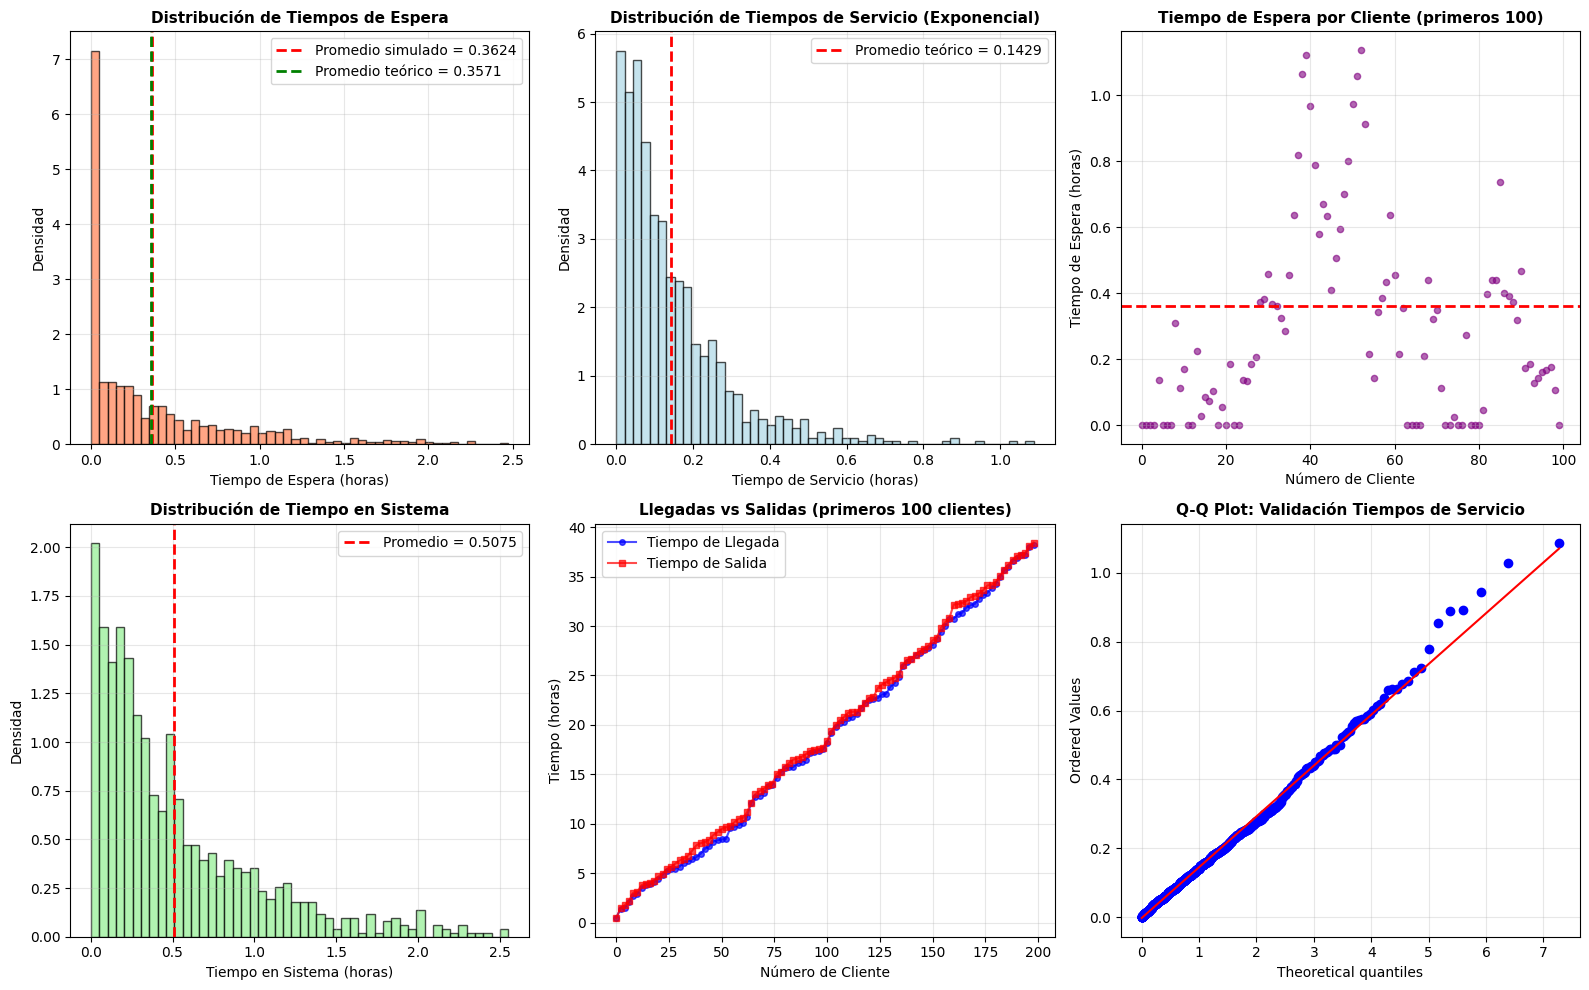


✓ Simulación de cola M/M/1 completada exitosamente


In [4]:
# Simulación de Cola M/M/1

# Parámetros del sistema
lambda_arrival = 5   # clientes/hora
mu_service = 7       # clientes/hora
n_customers = 1000

print("=" * 70)
print("SIMULACIÓN DE COLA M/M/1")
print("=" * 70)
print(f"Tasa de llegada (λ): {lambda_arrival} clientes/hora")
print(f"Tasa de servicio (μ): {mu_service} clientes/hora")
print(f"Intensidad de tráfico (ρ): {lambda_arrival/mu_service:.4f}")
print(f"Clientes simulados: {n_customers}")
print("-" * 70)

# Ejecutar simulación
results = simulate_mm1_queue(
    arrival_rate=lambda_arrival,
    service_rate=mu_service,
    n_customers=n_customers,
    random_state=RANDOM_STATE
)

# Calcular estadísticas adicionales
wait_times = results['wait_times']
sojourn_times = results['sojourn_times']

# Estadísticas de espera
print("\nESTADÍSTICAS DE ESPERA EN COLA:")
print(f"  Tiempo promedio (simulado): {results['mean_wait_simulated']:.6f} horas")
print(f"  Tiempo promedio (teórico):  {results['mean_wait_theoretical']:.6f} horas")
print(f"  Error: {abs(results['mean_wait_simulated'] - results['mean_wait_theoretical']):.6f} horas")
print(f"  Desv. Estándar: {np.std(wait_times):.6f} horas")
print(f"  Mínimo: {np.min(wait_times[wait_times > 0]):.6f} horas (excluyendo 0s)")
print(f"  Máximo: {np.max(wait_times):.6f} horas")

# Estadísticas de tiempo en sistema
print("\nESTADÍSTICAS DE TIEMPO EN SISTEMA:")
print(f"  Tiempo promedio: {np.mean(sojourn_times):.6f} horas")
print(f"  Desv. Estándar: {np.std(sojourn_times):.6f} horas")
print(f"  Mínimo: {np.min(sojourn_times):.6f} horas")
print(f"  Máximo: {np.max(sojourn_times):.6f} horas")

# Utilización del servidor
print("\nUTILIZACIÓN DEL SISTEMA:")
print(f"  ρ = λ/μ = {results['utilization']:.4f}")
print(f"  Probabilidad servidor ocupado: {results['utilization']*100:.2f}%")

# Visualizar resultados
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Distribución de tiempos de espera
axes[0, 0].hist(wait_times, bins=50, density=True, color='coral', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribución de Tiempos de Espera', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Tiempo de Espera (horas)')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].axvline(results['mean_wait_simulated'], color='red', linestyle='--', linewidth=2,
                   label=f'Promedio simulado = {results["mean_wait_simulated"]:.4f}')
axes[0, 0].axvline(results['mean_wait_theoretical'], color='green', linestyle='--', linewidth=2,
                   label=f'Promedio teórico = {results["mean_wait_theoretical"]:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribución de tiempos de servicio
axes[0, 1].hist(results['service_times'], bins=50, density=True, color='lightblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribución de Tiempos de Servicio (Exponencial)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Tiempo de Servicio (horas)')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].axvline(1/mu_service, color='red', linestyle='--', linewidth=2,
                   label=f'Promedio teórico = {1/mu_service:.4f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Evolución del tiempo de espera
axes[0, 2].scatter(range(min(100, n_customers)), wait_times[:min(100, n_customers)],
                   alpha=0.6, s=20, color='purple')
axes[0, 2].axhline(results['mean_wait_simulated'], color='red', linestyle='--', linewidth=2)
axes[0, 2].set_title('Tiempo de Espera por Cliente (primeros 100)', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('Número de Cliente')
axes[0, 2].set_ylabel('Tiempo de Espera (horas)')
axes[0, 2].grid(True, alpha=0.3)

# 4. Distribución de tiempo en sistema
axes[1, 0].hist(sojourn_times, bins=50, density=True, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribución de Tiempo en Sistema', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Tiempo en Sistema (horas)')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].axvline(np.mean(sojourn_times), color='red', linestyle='--', linewidth=2,
                   label=f'Promedio = {np.mean(sojourn_times):.4f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Tiempos de llegada acumulados vs tiempos de salida
sample_indices = range(0, min(200, n_customers), 2)
axes[1, 1].plot(sample_indices, results['arrival_times'][::2][:100], 'bo-',
               label='Tiempo de Llegada', markersize=4, alpha=0.7)
axes[1, 1].plot(sample_indices, results['finish_service'][::2][:100], 'rs-',
               label='Tiempo de Salida', markersize=4, alpha=0.7)
axes[1, 1].set_title('Llegadas vs Salidas (primeros 100 clientes)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Número de Cliente')
axes[1, 1].set_ylabel('Tiempo (horas)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Q-Q plot para validar exponencialidad
stats.probplot(results['service_times'], dist="expon", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q Plot: Validación Tiempos de Servicio', fontsize=11, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mm1_queue_simulation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Simulación de cola M/M/1 completada exitosamente")


## Ejercicios para el Estudiante

### Ejercicio 1: Efecto del Tamaño de Muestra en el TLC
Toma muestras de tamaños diferentes (n = 5, 10, 30, 50) de una población exponencial y visualiza cómo la distribución de medias muestrales se aproxima a la normal conforme n aumenta. ¿Cuál es el tamaño mínimo de muestra para que la aproximación sea "buena"?

**Hint**: Usa `np.histogram()` para bins comparables y compara con `stats.norm()`.

### Ejercicio 2: Análisis de Estabilidad de Colas
Ejecuta simulaciones M/M/1 con diferentes valores de ρ (0.3, 0.7, 0.95) y compara:
- Tiempos de espera promedio
- Variabilidad en tiempos
- Numero máximo en cola

¿Qué ocurre cuando ρ se acerca a 1?

### Ejercicio 3: Verificación de la Ley de Little
Usando los resultados de la simulación M/M/1:
1. Calcula L (número promedio en sistema)
2. Calcula W (tiempo promedio en sistema)
3. Verifica que L = λW

¿Se cumple la relación teóricamente esperada?
